# Task 1: Multimodal Item Embedding Notebook

This notebook is a self-contained Task 1 pipeline for learning **128-dimensional item embeddings**.

It uses the files present in `Project/Data`:

- `item_info.parquet`
- `item_feature.parquet`
- `train.parquet`
- `valid.parquet`
- `test.parquet`

For Task 1, the model learns item embeddings from:

- `txt_emb_BERT`: precomputed 768-dimensional text features
- `img_emb_CLIPRN50`: precomputed 1024-dimensional image features
- `item_tags`: categorical item metadata
- CTR supervision from user histories

Important Task 1 boundary:

- `item_info.parquet` is used for item ids, tags, and the required padding row `item_id=0`.
- The provided `item_emb_d128` column is **not** used as a model input or training target.
- The CTR head is auxiliary only; the final output is the learned item embedding matrix with shape `(num_items, 128)`.


## Notebook Roadmap

1. Import libraries
2. Define configs and helper utilities
3. Load the challenge data and build dataset objects
4. Define the Task 1 item encoder and auxiliary CTR training model
5. Inspect multimodal feature shapes
6. Run a small smoke-test training pass
7. Visualize loss and AUC curves
8. Export the learned 128-dimensional item embeddings
9. Optional: scale up to a larger training run


## 1. Imports

This section loads the libraries used throughout the notebook, including plotting utilities for monitoring training.


In [26]:
from __future__ import annotations

from dataclasses import asdict, dataclass, field
from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset


## 2. Config and Utility Functions

These dataclasses control paths, model sizes, and training hyperparameters. The helper functions handle seeds, device selection, masked pooling, JSON saving, and AUC computation.


In [27]:
@dataclass
class DataConfig:
    data_dir: str = 'Data'
    item_info_filename: str = 'item_info.parquet'
    item_feature_filename: str = 'item_feature.parquet'
    train_filename: str = 'train.parquet'
    valid_filename: str = 'valid.parquet'
    test_filename: str = 'test.parquet'
    history_length: int = 64
    pad_item_id: int = 0
    num_tag_slots: int = 5


@dataclass
class ModelConfig:
    item_embedding_dim: int = 128

    text_input_dim: int = 768
    text_feature_dim: int = 256

    image_input_dim: int = 1024
    image_feature_dim: int = 256

    tag_embedding_dim: int = 32
    tag_hidden_dim: int = 128
    metadata_feature_dim: int = 128

    fused_hidden_dim: int = 256
    dropout: float = 0.1
    use_l2_norm: bool = False

    user_num_layers: int = 2
    user_num_heads: int = 4
    user_dropout: float = 0.1
    max_history_length: int = 64

    context_embedding_dim: int = 16
    ctr_hidden_dim: int = 256


@dataclass
class TrainConfig:
    output_dir: str = 'outputs'
    run_name: str = 'notebook_run'
    batch_size: int = 2048
    eval_batch_size: int = 4096
    epochs: int = 5
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 0
    device: str = 'cuda'
    seed: int = 42
    log_every: int = 200
    label_smoothing: float = 0.0
    grad_clip_norm: float = 1.0


@dataclass
class ExperimentConfig:
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    train: TrainConfig = field(default_factory=TrainConfig)

    def save(self, path: str | Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2), encoding='utf-8')


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_device(requested: str) -> torch.device:
    if requested == 'cuda' and torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


def masked_mean(values: torch.Tensor, mask: torch.Tensor, dim: int) -> torch.Tensor:
    mask = mask.to(values.dtype)
    masked_values = values * mask.unsqueeze(-1)
    denom = mask.sum(dim=dim, keepdim=True).clamp_min(1.0)
    return masked_values.sum(dim=dim) / denom


def binary_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.int64)
    y_score = np.asarray(y_score, dtype=np.float64)

    pos = int((y_true == 1).sum())
    neg = int((y_true == 0).sum())
    if pos == 0 or neg == 0:
        return float('nan')

    order = np.argsort(y_score, kind='mergesort')
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, len(y_score) + 1, dtype=np.float64)

    sorted_scores = y_score[order]
    sorted_ranks = np.arange(1, len(y_score) + 1, dtype=np.float64)
    _, start_idx, counts = np.unique(
        sorted_scores,
        return_index=True,
        return_counts=True,
    )
    for start, count in zip(start_idx, counts):
        if count > 1:
            avg_rank = sorted_ranks[start:start + count].mean()
            ranks[order[start:start + count]] = avg_rank

    pos_rank_sum = ranks[y_true == 1].sum()
    auc = (pos_rank_sum - pos * (pos + 1) / 2.0) / (pos * neg)
    return float(auc)


def save_json(payload: dict, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding='utf-8')


def format_step(step: int, total_steps: int) -> str:
    width = max(1, int(math.log10(max(total_steps, 1))) + 1)
    return f'{step:>{width}}/{total_steps}'


## 3. Data Loading and Dataset Pipeline

This section reads the parquet files, builds a fast item feature store, and defines the CTR training dataset. Item id `0` is treated as the padding token for user history sequences.


In [28]:
@dataclass
class DataBundle:
    items: pd.DataFrame
    item_features: pd.DataFrame
    train: pd.DataFrame
    valid: pd.DataFrame
    test: pd.DataFrame


def load_data_bundle(config: DataConfig, root_dir: str | Path | None = None) -> DataBundle:
    root = Path(root_dir) if root_dir is not None else Path.cwd()
    data_dir = root / config.data_dir
    return DataBundle(
        items=pd.read_parquet(data_dir / config.item_info_filename),
        item_features=pd.read_parquet(data_dir / config.item_feature_filename),
        train=pd.read_parquet(data_dir / config.train_filename),
        valid=pd.read_parquet(data_dir / config.valid_filename),
        test=pd.read_parquet(data_dir / config.test_filename),
    )


class ItemFeatureStore:
    def __init__(
        self,
        item_frame: pd.DataFrame,
        item_feature_frame: pd.DataFrame | None = None,
        pad_item_id: int = 0,
    ) -> None:
        # item_info.parquet is the canonical item table because it includes item_id 0.
        # The padding row must stay present in every exported Task 1 embedding matrix.
        self.item_frame = item_frame.sort_values('item_id').reset_index(drop=True)
        self.item_feature_frame = None
        if item_feature_frame is not None:
            self.item_feature_frame = item_feature_frame.sort_values('item_id').reset_index(drop=True)
        self.pad_item_id = pad_item_id
        self.item_ids = torch.tensor(self.item_frame['item_id'].to_numpy(), dtype=torch.long)

        # Use item_info only for tags and padding compatibility.
        # We intentionally do NOT use item_info.item_emb_d128 as a feature for Task 1.
        self.tag_features = torch.tensor(
            np.asarray(self.item_frame['item_tags'].tolist(), dtype=np.int64),
            dtype=torch.long,
        )

        self.num_items = int(self.item_ids.numel())
        self.num_tag_slots = int(self.tag_features.shape[1])

        self._dense_lookup = bool(torch.equal(self.item_ids, torch.arange(self.item_ids.numel())))
        self._pad_index = int(pad_item_id)
        if not self._dense_lookup:
            self.item_id_to_index = {
                int(item_id): idx for idx, item_id in enumerate(self.item_frame['item_id'].tolist())
            }
            if pad_item_id not in self.item_id_to_index:
                raise ValueError(f'Padding item id {pad_item_id} is missing from item_info.parquet.')
            self._pad_index = int(self.item_id_to_index[pad_item_id])

        self.tag_cardinalities = [
            int(self.tag_features[:, slot].max().item()) + 1 for slot in range(self.num_tag_slots)
        ]

        # item_feature.parquet starts at item_id 1, so align it into the item_info index.
        # Row 0 remains all zeros for safe padding in user history sequences.
        self.text_embeddings = self._build_aligned_feature_tensor('txt_emb_BERT')
        self.image_embeddings = self._build_aligned_feature_tensor('img_emb_CLIPRN50')
        self.text_embedding_dim = int(self.text_embeddings.shape[-1])
        self.image_embedding_dim = int(self.image_embeddings.shape[-1])

    def _build_aligned_feature_tensor(self, column_name: str) -> torch.Tensor:
        if self.item_feature_frame is None or column_name not in self.item_feature_frame.columns:
            return torch.zeros(self.num_items, 0, dtype=torch.float32)

        first_value = self.item_feature_frame[column_name].iloc[0]
        feature_dim = int(len(first_value))
        aligned = np.zeros((self.num_items, feature_dim), dtype=np.float32)

        feature_item_ids = torch.tensor(
            self.item_feature_frame['item_id'].to_numpy(dtype=np.int64),
            dtype=torch.long,
        )
        aligned_indices = self.lookup_item_indices(feature_item_ids).cpu().numpy()
        feature_matrix = np.asarray(self.item_feature_frame[column_name].tolist(), dtype=np.float32)
        aligned[aligned_indices] = feature_matrix
        aligned[self._pad_index] = 0.0
        return torch.tensor(aligned, dtype=torch.float32)

    def lookup_item_indices(self, item_ids: torch.Tensor) -> torch.Tensor:
        if self._dense_lookup:
            indices = item_ids.clone()
            invalid = (indices < 0) | (indices >= self.num_items)
            indices[invalid] = self._pad_index
            return indices

        flat_ids = item_ids.detach().cpu().reshape(-1).tolist()
        indices = [self.item_id_to_index.get(int(item_id), self._pad_index) for item_id in flat_ids]
        return torch.tensor(indices, dtype=torch.long, device=item_ids.device).view_as(item_ids)

    def get_features(self, item_ids: torch.Tensor, device: torch.device | None = None) -> dict[str, torch.Tensor | None]:
        indices = self.lookup_item_indices(item_ids)
        lookup_indices = indices.detach().cpu()

        tags = self.tag_features[lookup_indices].to(item_ids.device)
        text_emb = self.text_embeddings[lookup_indices].to(item_ids.device)
        image_emb = self.image_embeddings[lookup_indices].to(item_ids.device)
        is_padding = item_ids.eq(self.pad_item_id)

        if device is not None:
            item_ids = item_ids.to(device)
            indices = indices.to(device)
            tags = tags.to(device)
            text_emb = text_emb.to(device)
            image_emb = image_emb.to(device)
            is_padding = is_padding.to(device)

        return {
            'item_ids': item_ids,
            'item_indices': indices,
            'tag_features': tags,
            'is_padding': is_padding,
            'text_embeddings': text_emb,
            'image_embeddings': image_emb,
        }


class CTRDataset(Dataset):
    """Lightweight CTR rows for auxiliary Task 1 training.

    The dataset returns item ids, context ids, and labels only.
    ItemFeatureStore converts item ids into text/image/tag tensors in prepare_batch().
    """

    def __init__(self, frame: pd.DataFrame, history_length: int = 64, with_labels: bool = True) -> None:
        seq = np.asarray(frame['item_seq'].tolist(), dtype=np.int64)
        if seq.shape[1] != history_length:
            raise ValueError(f'Expected history length {history_length}, found {seq.shape[1]}.')

        self.history_item_ids = torch.tensor(seq, dtype=torch.long)
        self.target_item_ids = torch.tensor(frame['item_id'].to_numpy(dtype=np.int64), dtype=torch.long)
        self.likes_level = torch.tensor(frame['likes_level'].to_numpy(dtype=np.int64) - 1, dtype=torch.long)
        self.views_level = torch.tensor(frame['views_level'].to_numpy(dtype=np.int64) - 1, dtype=torch.long)
        self.with_labels = with_labels
        self.labels = None
        if with_labels:
            self.labels = torch.tensor(frame['label'].to_numpy(dtype=np.float32), dtype=torch.float32)

    def __len__(self) -> int:
        return int(self.target_item_ids.shape[0])

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        sample = {
            'history_item_ids': self.history_item_ids[index],
            'target_item_id': self.target_item_ids[index],
            'likes_level': self.likes_level[index],
            'views_level': self.views_level[index],
        }
        if self.with_labels and self.labels is not None:
            sample['label'] = self.labels[index]
        return sample


## 4. Model Definition

The model has three main parts:

- an `ItemEncoder` that refines the provided 128-d item embedding using item tags,
- a `UserEncoder` that summarizes the user history sequence,
- a `CTRHead` that predicts click probability during training.

Only the learned item embeddings are exported at the end.


In [29]:
class TagEncoder(nn.Module):
    def __init__(
        self,
        tag_cardinalities: list[int],
        embedding_dim: int,
        hidden_dim: int,
        output_dim: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.slot_embeddings = nn.ModuleList(
            [nn.Embedding(cardinality, embedding_dim, padding_idx=0) for cardinality in tag_cardinalities]
        )
        self.projection = nn.Sequential(
            nn.Linear(len(tag_cardinalities) * embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
        )
        self.missing_embedding = nn.Parameter(torch.zeros(output_dim))

    def forward(self, tag_features: torch.Tensor) -> torch.Tensor:
        slot_vectors = []
        presence = []
        for slot, embedding in enumerate(self.slot_embeddings):
            slot_ids = tag_features[:, slot]
            slot_vectors.append(embedding(slot_ids))
            presence.append(slot_ids.ne(0))

        flat = torch.cat(slot_vectors, dim=-1)
        encoded = self.projection(flat)
        has_tag = torch.stack(presence, dim=-1).any(dim=-1)
        missing = self.missing_embedding.unsqueeze(0).expand_as(encoded)
        return torch.where(has_tag.unsqueeze(-1), encoded, missing)


class TextEncoder(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.projection = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, output_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim, output_dim),
            nn.LayerNorm(output_dim),
        )
        self.missing_embedding = nn.Parameter(torch.zeros(output_dim))

    def forward(self, text_embeddings: torch.Tensor | None, batch_size: int, device: torch.device) -> torch.Tensor:
        if text_embeddings is None or text_embeddings.numel() == 0:
            return self.missing_embedding.unsqueeze(0).expand(batch_size, -1).to(device)

        text_embeddings = text_embeddings.to(device)
        # text_embeddings shape: [batch_size, 768]
        encoded = self.projection(text_embeddings)
        # encoded shape: [batch_size, 256]
        has_text = text_embeddings.abs().sum(dim=-1).gt(0)
        missing = self.missing_embedding.unsqueeze(0).expand_as(encoded)
        return torch.where(has_text.unsqueeze(-1), encoded, missing)


class ImageEncoder(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.projection = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, output_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim, output_dim),
            nn.LayerNorm(output_dim),
        )
        self.missing_embedding = nn.Parameter(torch.zeros(output_dim))

    def forward(self, image_embeddings: torch.Tensor | None, batch_size: int, device: torch.device) -> torch.Tensor:
        if image_embeddings is None or image_embeddings.numel() == 0:
            return self.missing_embedding.unsqueeze(0).expand(batch_size, -1).to(device)

        image_embeddings = image_embeddings.to(device)
        # image_embeddings shape: [batch_size, 1024]
        encoded = self.projection(image_embeddings)
        # encoded shape: [batch_size, 256]
        has_image = image_embeddings.abs().sum(dim=-1).gt(0)
        missing = self.missing_embedding.unsqueeze(0).expand_as(encoded)
        return torch.where(has_image.unsqueeze(-1), encoded, missing)


class MetadataEncoder(nn.Module):
    def __init__(self, tag_cardinalities: list[int], config: ModelConfig) -> None:
        super().__init__()
        self.tag_encoder = TagEncoder(
            tag_cardinalities=tag_cardinalities,
            embedding_dim=config.tag_embedding_dim,
            hidden_dim=config.tag_hidden_dim,
            output_dim=config.metadata_feature_dim,
            dropout=config.dropout,
        )

    def forward(self, tag_features: torch.Tensor) -> torch.Tensor:
        metadata_features = self.tag_encoder(tag_features)
        # metadata_features shape: [batch_size, metadata_feature_dim]
        return metadata_features


class ItemEncoder(nn.Module):
    def __init__(self, tag_cardinalities: list[int], config: ModelConfig) -> None:
        super().__init__()
        self.config = config
        self.text_encoder = TextEncoder(
            input_dim=config.text_input_dim,
            output_dim=config.text_feature_dim,
            dropout=config.dropout,
        )
        self.image_encoder = ImageEncoder(
            input_dim=config.image_input_dim,
            output_dim=config.image_feature_dim,
            dropout=config.dropout,
        )
        self.metadata_encoder = MetadataEncoder(
            tag_cardinalities=tag_cardinalities,
            config=config,
        )
        fusion_input_dim = config.text_feature_dim + config.image_feature_dim + config.metadata_feature_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_input_dim, config.fused_hidden_dim),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.fused_hidden_dim, config.item_embedding_dim),
        )
        self.output_norm = nn.LayerNorm(config.item_embedding_dim)
        self.use_l2_norm = config.use_l2_norm

    @staticmethod
    def _require_tensor(item_features: dict[str, torch.Tensor | None], key: str) -> torch.Tensor:
        value = item_features.get(key)
        if value is None:
            raise KeyError(f"ItemEncoder.forward expected item_features['{key}'] to be a tensor.")
        return value

    @staticmethod
    def _check_2d(name: str, value: torch.Tensor | None, expected_dim: int | None, batch_size: int) -> None:
        if value is None:
            return
        if value.ndim != 2:
            raise ValueError(f"{name} must be 2D with shape [batch_size, feature_dim], got {tuple(value.shape)}.")
        if value.shape[0] != batch_size:
            raise ValueError(f"{name} batch size must be {batch_size}, got {value.shape[0]}.")
        if expected_dim is not None and value.shape[1] != expected_dim:
            raise ValueError(f"{name} feature dim must be {expected_dim}, got {value.shape[1]}.")

    def forward(self, item_features: dict[str, torch.Tensor | None]) -> torch.Tensor:
        """Encode items for Task 1 from multimodal item features.

        Expected dictionary keys:
        - tag_features: Tensor [batch_size, num_tag_slots]
        - text_embeddings: Tensor [batch_size, 768]
        - image_embeddings: Tensor [batch_size, 1024]
        - is_padding: optional Bool Tensor [batch_size], true for item_id 0
        """
        tag_features = self._require_tensor(item_features, 'tag_features')
        text_embeddings = item_features.get('text_embeddings')
        image_embeddings = item_features.get('image_embeddings')
        is_padding = item_features.get('is_padding')

        batch_size = int(tag_features.shape[0])
        device = tag_features.device

        self._check_2d('tag_features', tag_features, None, batch_size)
        self._check_2d('text_embeddings', text_embeddings, self.config.text_input_dim, batch_size)
        self._check_2d('image_embeddings', image_embeddings, self.config.image_input_dim, batch_size)
        if is_padding is not None and is_padding.shape[0] != batch_size:
            raise ValueError(f"is_padding must have shape [batch_size], got {tuple(is_padding.shape)}.")

        text_features = self.text_encoder(
            text_embeddings=text_embeddings,
            batch_size=batch_size,
            device=device,
        )
        # text_features shape: [batch_size, 256]

        image_features = self.image_encoder(
            image_embeddings=image_embeddings,
            batch_size=batch_size,
            device=device,
        )
        # image_features shape: [batch_size, 256]

        metadata_features = self.metadata_encoder(tag_features=tag_features)
        # metadata_features shape: [batch_size, metadata_feature_dim]

        fused_features = torch.cat([text_features, image_features, metadata_features], dim=-1)
        # fused_features shape: [batch_size, 256 + 256 + metadata_feature_dim]

        item_embeddings = self.output_norm(self.fusion(fused_features))
        # item_embeddings shape: [batch_size, 128]

        if self.use_l2_norm:
            item_embeddings = F.normalize(item_embeddings, dim=-1)

        if is_padding is not None:
            item_embeddings = torch.where(
                is_padding.to(device).bool().unsqueeze(-1),
                torch.zeros_like(item_embeddings),
                item_embeddings,
            )
        return item_embeddings


class UserEncoder(nn.Module):
    def __init__(self, config: ModelConfig) -> None:
        super().__init__()
        self.position_embeddings = nn.Embedding(config.max_history_length, config.item_embedding_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.item_embedding_dim,
            nhead=config.user_num_heads,
            dim_feedforward=config.fused_hidden_dim * 2,
            dropout=config.user_dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer=encoder_layer, num_layers=config.user_num_layers)
        self.empty_history = nn.Parameter(torch.zeros(config.item_embedding_dim))

    def forward(self, history_embeddings: torch.Tensor, history_mask: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = history_embeddings.shape
        positions = torch.arange(sequence_length, device=history_embeddings.device)
        hidden = history_embeddings + self.position_embeddings(positions).unsqueeze(0)
        hidden = self.encoder(hidden, src_key_padding_mask=~history_mask)
        pooled = masked_mean(hidden, history_mask, dim=1)
        empty = self.empty_history.unsqueeze(0).expand(batch_size, -1)
        has_history = history_mask.any(dim=1)
        return torch.where(has_history.unsqueeze(-1), pooled, empty)


class ContextFeatureEncoder(nn.Module):
    def __init__(self, embedding_dim: int) -> None:
        super().__init__()
        self.likes_embedding = nn.Embedding(10, embedding_dim)
        self.views_embedding = nn.Embedding(10, embedding_dim)
        self.projection = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim * 2),
            nn.GELU(),
            nn.Linear(embedding_dim * 2, embedding_dim),
        )

    def forward(self, likes_level: torch.Tensor, views_level: torch.Tensor) -> torch.Tensor:
        likes = self.likes_embedding(likes_level)
        views = self.views_embedding(views_level)
        return self.projection(torch.cat([likes, views], dim=-1))


class CTRHead(nn.Module):
    def __init__(self, item_dim: int, context_dim: int, hidden_dim: int, dropout: float) -> None:
        super().__init__()
        interaction_dim = item_dim * 4 + context_dim + 1
        self.layers = nn.Sequential(
            nn.Linear(interaction_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, user_embedding: torch.Tensor, item_embedding: torch.Tensor, context_embedding: torch.Tensor) -> torch.Tensor:
        dot_product = (user_embedding * item_embedding).sum(dim=-1, keepdim=True)
        features = torch.cat(
            [
                user_embedding,
                item_embedding,
                torch.abs(user_embedding - item_embedding),
                user_embedding * item_embedding,
                context_embedding,
                dot_product,
            ],
            dim=-1,
        )
        return self.layers(features).squeeze(-1)


class CTRModel(nn.Module):
    """Auxiliary CTR model used only to train Task 1 item embeddings."""

    def __init__(self, tag_cardinalities: list[int], config: ModelConfig) -> None:
        super().__init__()
        self.item_encoder = ItemEncoder(tag_cardinalities=tag_cardinalities, config=config)
        self.user_encoder = UserEncoder(config=config)
        self.context_encoder = ContextFeatureEncoder(config.context_embedding_dim)
        self.ctr_head = CTRHead(
            item_dim=config.item_embedding_dim,
            context_dim=config.context_embedding_dim,
            hidden_dim=config.ctr_hidden_dim,
            dropout=config.dropout,
        )

    def encode_items(self, item_features: dict[str, torch.Tensor | None]) -> torch.Tensor:
        return self.item_encoder(item_features)

    def forward(
        self,
        target_features: dict[str, torch.Tensor | None],
        history_features: dict[str, torch.Tensor | None],
        history_mask: torch.Tensor,
        likes_level: torch.Tensor,
        views_level: torch.Tensor,
    ) -> dict[str, torch.Tensor]:
        target_embeddings = self.item_encoder(target_features)

        batch_size, history_length = history_mask.shape
        history_embeddings = self.item_encoder(history_features).view(batch_size, history_length, -1)
        user_embeddings = self.user_encoder(history_embeddings, history_mask)
        context_embeddings = self.context_encoder(likes_level, views_level)
        logits = self.ctr_head(user_embeddings, target_embeddings, context_embeddings)
        return {
            'logits': logits,
            'target_embeddings': target_embeddings,
            'user_embeddings': user_embeddings,
        }


In [30]:
data_config = DataConfig()
bundle = load_data_bundle(data_config)
item_store = ItemFeatureStore(
    bundle.items,
    item_feature_frame=bundle.item_features,
    pad_item_id=data_config.pad_item_id,
)

debug_dataset = CTRDataset(
    bundle.train.head(2),
    history_length=data_config.history_length,
    with_labels=True,
)

sample = debug_dataset[0]
target_features = item_store.get_features(sample['target_item_id'].unsqueeze(0))
padding_features = item_store.get_features(torch.tensor([data_config.pad_item_id]))
print('target_item_id:', sample['target_item_id'].item())
print('dataset keys:', sorted(sample.keys()))
print('feature store keys:', sorted(target_features.keys()))
print('tag_features shape:', target_features['tag_features'].shape)
print('text_embeddings shape:', target_features['text_embeddings'].shape)
print('image_embeddings shape:', target_features['image_embeddings'].shape)
print('padding text sum:', float(padding_features['text_embeddings'].abs().sum()))
print('padding image sum:', float(padding_features['image_embeddings'].abs().sum()))

model_config = ModelConfig(max_history_length=data_config.history_length)
item_encoder = ItemEncoder(item_store.tag_cardinalities, model_config)
with torch.no_grad():
    item_embedding = item_encoder(target_features)
    padding_embedding = item_encoder(padding_features)
print('ItemEncoder output shape:', item_embedding.shape)
print('Padding embedding sum:', float(padding_embedding.abs().sum()))


target_item_id: 33811
dataset keys: ['history_item_ids', 'label', 'likes_level', 'target_item_id', 'views_level']
feature store keys: ['image_embeddings', 'is_padding', 'item_ids', 'item_indices', 'tag_features', 'text_embeddings']
tag_features shape: torch.Size([1, 5])
text_embeddings shape: torch.Size([1, 768])
image_embeddings shape: torch.Size([1, 1024])
padding text sum: 0.0
padding image sum: 0.0
ItemEncoder output shape: torch.Size([1, 128])
Padding embedding sum: 0.0


## 5. Training and Export Helpers

This section handles batch preparation, loss computation, epoch execution, experiment training, metric plotting, and final embedding export.


In [31]:
def prepare_batch(batch: dict[str, torch.Tensor], item_store: ItemFeatureStore, device: torch.device) -> dict[str, torch.Tensor | dict[str, torch.Tensor]]:
    target_item_ids = batch['target_item_id'].to(device)
    history_item_ids = batch['history_item_ids'].to(device)
    history_mask = history_item_ids.ne(item_store.pad_item_id)

    # Dataset gives ids only; ItemFeatureStore converts ids to multimodal tensors here.
    # target_item_ids shape: [batch_size]
    # history_item_ids flattened shape: [batch_size * history_length]
    target_features = item_store.get_features(target_item_ids, device=device)
    history_features = item_store.get_features(history_item_ids.reshape(-1), device=device)

    prepared = {
        'target_features': target_features,
        'history_features': history_features,
        'history_mask': history_mask,
        'likes_level': batch['likes_level'].to(device),
        'views_level': batch['views_level'].to(device),
    }
    if 'label' in batch:
        prepared['label'] = batch['label'].to(device)
    return prepared


def compute_loss(
    outputs: dict[str, torch.Tensor],
    batch: dict[str, torch.Tensor | dict[str, torch.Tensor]],
    label_smoothing: float,
) -> torch.Tensor:
    labels = batch['label']
    if label_smoothing > 0:
        labels = labels * (1.0 - label_smoothing) + 0.5 * label_smoothing

    # Task 1 uses CTR supervision as an auxiliary signal only.
    # No provided 128-d item embedding is used as an anchor target.
    return F.binary_cross_entropy_with_logits(outputs['logits'], labels)
def run_epoch(
    model: CTRModel,
    loader: DataLoader,
    item_store: ItemFeatureStore,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
    train_config: TrainConfig,
) -> tuple[float, float]:
    is_training = optimizer is not None
    model.train(is_training)

    all_labels = []
    all_scores = []
    total_loss = 0.0
    total_examples = 0
    total_steps = len(loader)
    start_time = time.time()

    for step, raw_batch in enumerate(loader, start=1):
        batch = prepare_batch(raw_batch, item_store=item_store, device=device)

        with torch.set_grad_enabled(is_training):
            outputs = model(
                target_features=batch['target_features'],
                history_features=batch['history_features'],
                history_mask=batch['history_mask'],
                likes_level=batch['likes_level'],
                views_level=batch['views_level'],
            )
            loss = compute_loss(
                outputs=outputs,
                batch=batch,
                label_smoothing=train_config.label_smoothing,
            )

        if is_training:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), train_config.grad_clip_norm)
            optimizer.step()

        batch_size = int(raw_batch['target_item_id'].shape[0])
        total_loss += float(loss.item()) * batch_size
        total_examples += batch_size

        labels = batch['label']
        all_labels.append(labels.detach().cpu().numpy())
        all_scores.append(torch.sigmoid(outputs['logits']).detach().cpu().numpy())

        if is_training and step % train_config.log_every == 0:
            elapsed = time.time() - start_time
            print(f"train step {format_step(step, total_steps)} loss={loss.item():.4f} elapsed={elapsed:.1f}s")

    mean_loss = total_loss / max(total_examples, 1)
    auc = binary_auc(np.concatenate(all_labels), np.concatenate(all_scores))
    return mean_loss, auc


def train_experiment(
    data_config: DataConfig,
    model_config: ModelConfig,
    train_config: TrainConfig,
    train_limit: int | None = None,
    valid_limit: int | None = None,
) -> tuple[CTRModel, ItemFeatureStore, dict]:
    set_seed(train_config.seed)
    device = resolve_device(train_config.device)
    output_dir = Path(train_config.output_dir) / train_config.run_name
    output_dir.mkdir(parents=True, exist_ok=True)

    experiment = ExperimentConfig(data=data_config, model=model_config, train=train_config)
    bundle = load_data_bundle(data_config, root_dir=Path.cwd())
    if train_limit is not None:
        bundle.train = bundle.train.sample(
            n=min(train_limit, len(bundle.train)),
            random_state=train_config.seed,
        ).reset_index(drop=True)
    if valid_limit is not None:
        bundle.valid = bundle.valid.sample(
            n=min(valid_limit, len(bundle.valid)),
            random_state=train_config.seed,
        ).reset_index(drop=True)

    item_store = ItemFeatureStore(
        bundle.items,
        item_feature_frame=bundle.item_features,
        pad_item_id=data_config.pad_item_id,
    )
    train_dataset = CTRDataset(
        bundle.train,
        history_length=data_config.history_length,
        with_labels=True,
    )
    valid_dataset = CTRDataset(
        bundle.valid,
        history_length=data_config.history_length,
        with_labels=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_config.batch_size,
        shuffle=True,
        num_workers=train_config.num_workers,
        pin_memory=device.type == 'cuda',
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=train_config.eval_batch_size,
        shuffle=False,
        num_workers=train_config.num_workers,
        pin_memory=device.type == 'cuda',
    )

    model = CTRModel(tag_cardinalities=item_store.tag_cardinalities, config=model_config).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=train_config.learning_rate,
        weight_decay=train_config.weight_decay,
    )

    best_valid_auc = float('-inf')
    metrics_history = []

    for epoch in range(1, train_config.epochs + 1):
        print(f'epoch {epoch}/{train_config.epochs}')
        train_loss, train_auc = run_epoch(model, train_loader, item_store, optimizer, device, train_config)
        valid_loss, valid_auc = run_epoch(model, valid_loader, item_store, None, device, train_config)

        epoch_metrics = {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_auc': train_auc,
            'valid_loss': valid_loss,
            'valid_auc': valid_auc,
        }
        metrics_history.append(epoch_metrics)
        print(
            f"epoch {epoch} train_loss={train_loss:.4f} train_auc={train_auc:.4f} "
            f"valid_loss={valid_loss:.4f} valid_auc={valid_auc:.4f}"
        )

        checkpoint = {
            'model_state_dict': model.state_dict(),
            'model_config': asdict(model_config),
            'data_config': asdict(data_config),
            'train_config': asdict(train_config),
            'tag_cardinalities': item_store.tag_cardinalities,
        }
        torch.save(checkpoint, output_dir / 'last_model.pt')
        if valid_auc > best_valid_auc:
            best_valid_auc = valid_auc
            torch.save(checkpoint, output_dir / 'best_model.pt')

        save_json({'history': metrics_history, 'best_valid_auc': best_valid_auc}, output_dir / 'metrics.json')
        experiment.save(output_dir / 'config.json')

    return model, item_store, {
        'history': metrics_history,
        'best_valid_auc': best_valid_auc,
        'output_dir': str(output_dir),
    }


def plot_training_curves(metrics: dict) -> None:
    history = metrics.get('history', [])
    if not history:
        print('No training history found to plot.')
        return

    history_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(history_df['epoch'], history_df['valid_loss'], marker='o', label='Valid Loss')
    axes[0].set_title('Loss by Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_auc'], marker='o', label='Train AUC')
    axes[1].plot(history_df['epoch'], history_df['valid_auc'], marker='o', label='Valid AUC')
    axes[1].set_title('AUC by Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def export_item_embeddings(
    model: CTRModel,
    item_store: ItemFeatureStore,
    output_dir: str | Path,
    batch_size: int = 8192,
    device: str = 'cuda',
) -> tuple[np.ndarray, np.ndarray]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    torch_device = resolve_device(device)

    model = model.to(torch_device)
    model.eval()

    item_ids = item_store.item_ids.numpy()
    all_embeddings = []
    with torch.no_grad():
        for start in range(0, item_ids.shape[0], batch_size):
            batch_item_ids = item_store.item_ids[start:start + batch_size].to(torch_device)
            batch_features = item_store.get_features(batch_item_ids, device=torch_device)
            embeddings = model.encode_items(batch_features)
            all_embeddings.append(embeddings.cpu().numpy())

    stacked = np.concatenate(all_embeddings, axis=0).astype(np.float32)
    np.save(output_dir / 'item_embeddings.npy', stacked)
    np.save(output_dir / 'item_ids.npy', item_ids)
    print(f'saved embeddings to {output_dir / "item_embeddings.npy"}')
    return stacked, item_ids


## 6. Inspect the Dataset

Run the next cell once to confirm the parquet files load correctly and match the schema expected by the notebook.


In [32]:
data_config = DataConfig()
bundle = load_data_bundle(data_config)

print('item_info shape:', bundle.items.shape)
print('item_feature shape:', bundle.item_features.shape)
print('train shape:', bundle.train.shape)
print('valid shape:', bundle.valid.shape)
print('test shape:', bundle.test.shape)
print('item_info columns:', list(bundle.items.columns))
print('item_feature columns:', list(bundle.item_features.columns))
print('train columns:', list(bundle.train.columns))

bundle.item_features.head()


item_info shape: (91718, 3)
item_feature shape: (91717, 7)
train shape: (3600000, 6)
valid shape: (10000, 6)
test shape: (379142, 6)
item_info columns: ['item_id', 'item_tags', 'item_emb_d128']
item_feature columns: ['item_id', 'item_title', 'item_tags', 'likes_level', 'views_level', 'txt_emb_BERT', 'img_emb_CLIPRN50']
train columns: ['user_id', 'item_seq', 'item_id', 'likes_level', 'views_level', 'label']


,item_id,item_title,item_tags,likes_level,views_level,txt_emb_BERT,img_emb_CLIPRN50
0,1,Leian #TheLastKnightAmmishu #OriginalOutsideTh...,[1],7,2,"[-0.35627136, 0.29088444, -0.3601495, -0.26140...","[0.02026446, 0.0504134, 0.038729552, -0.001446..."
1,2,"If the heart is gone, use a stone to make it p...","[2, 3, 4]",5,9,"[-0.32983607, 0.3043856, -0.13676094, -0.01752...","[0.006481897, -0.018151272, -0.00074562244, -0..."
2,3,"""I Lead the Empress to Battle the Three Realms...","[5, 6, 7]",2,2,"[-0.25158748, 0.369733, -0.0891795, -0.1076934...","[-0.028488722, -0.003907809, -0.013114494, 0.0..."
3,4,It's all superfluous! #Naruto #NarutoMobile,"[8, 9]",2,1,"[-0.4750408, 0.1370452, -0.3940854, -0.3176355...","[0.0004695151, -0.012785373, 0.04488068, 0.001..."
4,5,#NoHeartbeatChallenge made me drool a little #...,"[10, 11, 12]",7,5,"[-0.52664506, 0.38321885, -0.4115216, -0.35488...","[-0.036545713, -0.012415022, -0.0019222107, 0...."


## 7. Run a Smoke Test Training Pass

This uses a small subset of the data so you can verify the full pipeline quickly before running a larger experiment.


In [33]:
data_config = DataConfig()
model_config = ModelConfig(max_history_length=data_config.history_length)
train_config = TrainConfig(
    run_name='notebook_smoke_test',
    epochs=1,
    batch_size=64,
    eval_batch_size=128,
    device='cuda',
    log_every=4,
)

model, item_store, metrics = train_experiment(
    data_config=data_config,
    model_config=model_config,
    train_config=train_config,
    train_limit=512,
    valid_limit=256,
)

metrics


epoch 1/1
train step 4/8 loss=0.7006 elapsed=3.0s
train step 8/8 loss=0.5269 elapsed=5.2s
epoch 1 train_loss=0.5513 train_auc=0.5206 valid_loss=0.5937 valid_auc=0.4722


{'history': [{'epoch': 1,
   'train_loss': 0.5512830764055252,
   'train_auc': 0.5206353485655232,
   'valid_loss': 0.5937295258045197,
   'valid_auc': 0.47217358203273696}],
 'best_valid_auc': 0.47217358203273696,
 'output_dir': 'outputs\\notebook_smoke_test'}

## 8. Plot Training Curves

After training finishes, use this cell to visualize the train and validation loss/AUC stored in `metrics`.


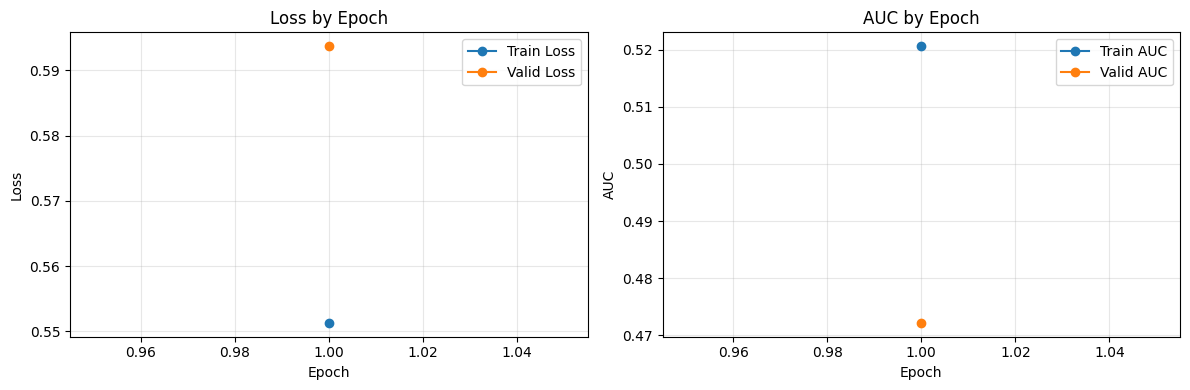

,epoch,train_loss,train_auc,valid_loss,valid_auc
0,1,0.551283,0.520635,0.59373,0.472174


In [34]:
plot_training_curves(metrics)

pd.DataFrame(metrics['history'])


## 9. Overfitting Smoke Test

This optional smoke test trains for a few epochs on a modest random subset. Use it to check whether train AUC improves while validation AUC gets worse, which is the main sign of overfitting.

Run this only after the quick smoke test works. It is still much smaller than the full run, but it will take longer than the one-epoch smoke test.


epoch 1/3
train step 20/20 loss=0.5521 elapsed=72.5s
epoch 1 train_loss=0.5833 train_auc=0.5036 valid_loss=0.5923 valid_auc=0.4799
epoch 2/3
train step 20/20 loss=0.5804 elapsed=67.8s
epoch 2 train_loss=0.5649 train_auc=0.5659 valid_loss=0.5996 valid_auc=0.4882
epoch 3/3
train step 20/20 loss=0.5299 elapsed=65.4s
epoch 3 train_loss=0.5551 train_auc=0.6131 valid_loss=0.6225 valid_auc=0.5053


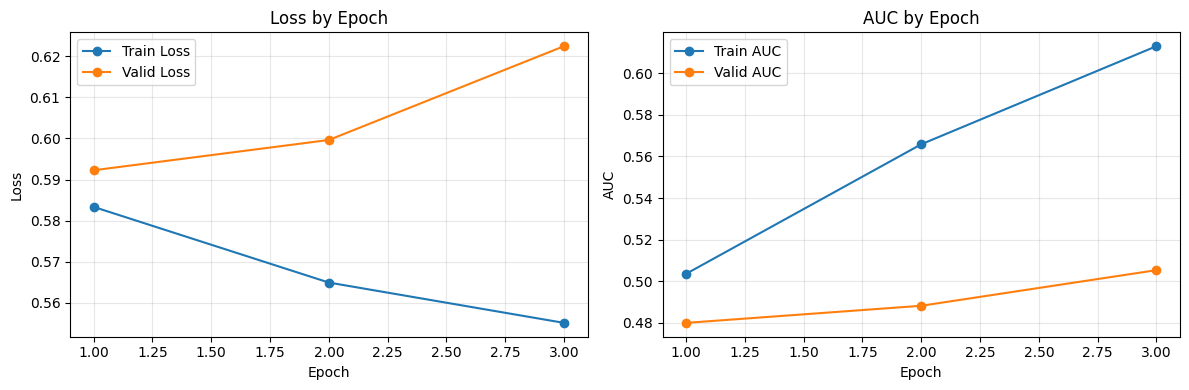

,epoch,train_loss,train_auc,valid_loss,valid_auc
0,1,0.583333,0.503551,0.592261,0.479944
1,2,0.564906,0.565886,0.599639,0.488180
2,3,0.555083,0.613070,0.622491,0.505323


train_auc_delta: 0.1095
valid_auc_delta: 0.0254
final_auc_gap: 0.1077
Possible overfitting: train AUC is much higher than validation AUC.


In [37]:
data_config = DataConfig()
model_config = ModelConfig(
    max_history_length=data_config.history_length,
    dropout=0.25,
    user_num_layers=1,
    user_num_heads=2,
    fused_hidden_dim=192,
    ctr_hidden_dim=192,
)
train_config = TrainConfig(
    run_name='overfit_smoke_test',
    epochs=3,
    batch_size=512,
    eval_batch_size=1024,
    learning_rate=3e-4,
    weight_decay=5e-4,
    device='cuda',
    log_every=20,
)

model, item_store, overfit_metrics = train_experiment(
    data_config=data_config,
    model_config=model_config,
    train_config=train_config,
    train_limit=10000,
    valid_limit=5000,
)

plot_training_curves(overfit_metrics)
overfit_history = pd.DataFrame(overfit_metrics['history'])
display(overfit_history)

train_auc_delta = overfit_history['train_auc'].iloc[-1] - overfit_history['train_auc'].iloc[0]
valid_auc_delta = overfit_history['valid_auc'].iloc[-1] - overfit_history['valid_auc'].iloc[0]
auc_gap = overfit_history['train_auc'].iloc[-1] - overfit_history['valid_auc'].iloc[-1]

print(f'train_auc_delta: {train_auc_delta:.4f}')
print(f'valid_auc_delta: {valid_auc_delta:.4f}')
print(f'final_auc_gap: {auc_gap:.4f}')

if auc_gap > 0.10 and valid_auc_delta <= 0:
    print('Overfitting warning: train AUC improved while validation AUC did not improve.')
elif auc_gap > 0.10:
    print('Possible overfitting: train AUC is much higher than validation AUC.')
else:
    print('No strong overfitting signal in this smoke test.')


epoch 1/2
train step 50/98 loss=0.5719 elapsed=182.3s
epoch 1 train_loss=0.5586 train_auc=0.5667 valid_loss=0.6197 valid_auc=0.4196
epoch 2/2
train step 50/98 loss=0.5395 elapsed=160.7s
epoch 2 train_loss=0.5181 train_auc=0.6921 valid_loss=0.6676 valid_auc=0.4304


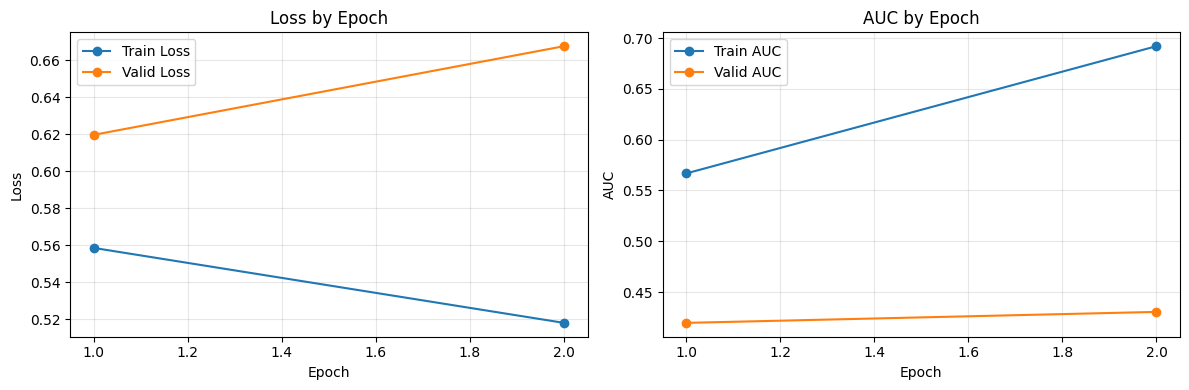

,epoch,train_loss,train_auc,valid_loss,valid_auc
0,1,0.558596,0.566736,0.619687,0.419618
1,2,0.518078,0.692061,0.667619,0.430437


In [39]:
data_config = DataConfig()

model_config = ModelConfig(
    max_history_length=data_config.history_length,
    dropout=0.25,
    user_num_layers=1,
    user_num_heads=2,
    fused_hidden_dim=192,
    ctr_hidden_dim=192,
)

train_config = TrainConfig(
    run_name='larger_task1_test',
    epochs=2,
    batch_size=512,
    eval_batch_size=1024,
    learning_rate=3e-4,
    weight_decay=5e-4,
    device='cuda',
    log_every=50,
)

model, item_store, metrics = train_experiment(
    data_config=data_config,
    model_config=model_config,
    train_config=train_config,
    train_limit=50000,
    valid_limit=10000,
)

plot_training_curves(metrics)
pd.DataFrame(metrics['history'])


## 10. Export Learned Item Embeddings

This step runs every item through the learned `ItemEncoder` and saves the final `128`-dimensional vectors.


In [ ]:
embeddings, item_ids = export_item_embeddings(
    model=model,
    item_store=item_store,
    output_dir=Path('outputs') / train_config.run_name,
    batch_size=4096,
    device=train_config.device,
)

print('embedding matrix shape:', embeddings.shape)
print('item ids shape:', item_ids.shape)
print('padding embedding sum:', float(np.abs(embeddings[0]).sum()))


## 11. Full Training Template

Once the smoke test works, switch to a larger run by uncommenting the next cell.


In [ ]:
# Optional larger run.
# Keep this cell commented until the smoke test and export both work.
#
# data_config = DataConfig()
# model_config = ModelConfig(
#     max_history_length=data_config.history_length,
#     dropout=0.25,
#     user_num_layers=1,
#     user_num_heads=2,
#     fused_hidden_dim=192,
#     ctr_hidden_dim=192,
# )
# train_config = TrainConfig(
#     run_name='larger_task1_run',
#     epochs=1,
#     batch_size=512,
#     eval_batch_size=1024,
#     learning_rate=3e-4,
#     weight_decay=5e-4,
#     device='cuda',
#     log_every=20,
# )
#
# model, item_store, metrics = train_experiment(
#     data_config=data_config,
#     model_config=model_config,
#     train_config=train_config,
#     train_limit=50000,
#     valid_limit=10000,
# )
#
# plot_training_curves(metrics)
# pd.DataFrame(metrics['history'])
#
# embeddings, item_ids = export_item_embeddings(
#     model=model,
#     item_store=item_store,
#     output_dir=Path('outputs') / train_config.run_name,
#     batch_size=8192,
#     device=train_config.device,
# )
